In [1]:
import os
os.chdir('../..')

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from src.datasets import QM9Dataset

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qm9 = QM9Dataset()
df = qm9.load()

2026-02-11 10:07:32.806 | INFO     | src.datasets:load:64 - Loading QM9 from data/QM9/dataset_cleaned.csv...


In [4]:
df

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558


# Visualization of a few molecules
- Ensuring that SMILES works for generating unique identifiers for each molecule

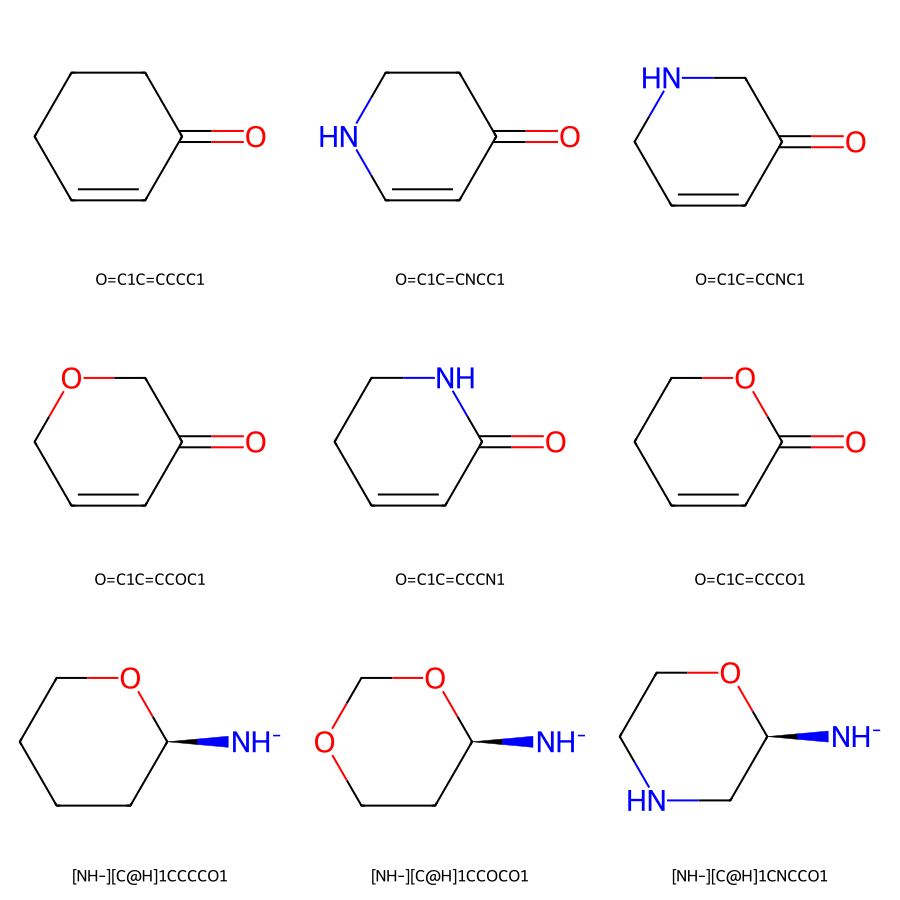

In [6]:
sample_smiles = df.tail(9)["canonical_smiles"].to_list()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img